# 1. Preprocessing and exploratory data analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
DATA_PATH = Path("../data")
FIGURES_PATH = Path("../figures")
FIGURES_PATH.mkdir(exist_ok=True)

## Load dataset

In [2]:
bank_data = pd.read_csv(DATA_PATH / "bank-additional-full.csv", sep=";")
bank_data.shape

(41188, 21)

In [3]:
bank_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Data types and missing values

In [4]:
bank_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

## Proportion of "unknown" values per categorical column

In [5]:
categorical_columns = bank_data.select_dtypes(exclude="number").columns
(bank_data[categorical_columns] == "unknown").mean().sort_values(ascending=False)

default        0.208726
education      0.042027
housing        0.024036
loan           0.024036
job            0.008012
marital        0.001942
contact        0.000000
month          0.000000
day_of_week    0.000000
poutcome       0.000000
y              0.000000
dtype: float64

## Remove duplicate rows

In [6]:
bank_data.duplicated().sum()

np.int64(12)

In [7]:
bank_data = bank_data.drop_duplicates()
bank_data.shape

(41176, 21)

## Target encoding: yes → 1, no → 0

In [8]:
bank_data["y"] = (bank_data["y"] == "yes").astype(int)
bank_data["y"].value_counts(normalize=True)

y
0    0.887337
1    0.112663
Name: proportion, dtype: float64

## 80/20 stratified split of data in train and test

In [9]:
train_data, test_data = train_test_split(
    bank_data,
    test_size=0.2,
    stratify=bank_data["y"],
    random_state=RANDOM_STATE,
)
print(train_data.shape, test_data.shape)
print(train_data["y"].mean(), test_data["y"].mean())

(32940, 21) (8236, 21)
0.11265938069216758 0.11267605633802817


## Save raw train and test sets

In [10]:
train_data.to_csv(DATA_PATH / "train.csv", index=False)
test_data.to_csv(DATA_PATH / "test.csv", index=False)

# EDA (train set only)

## Class balance

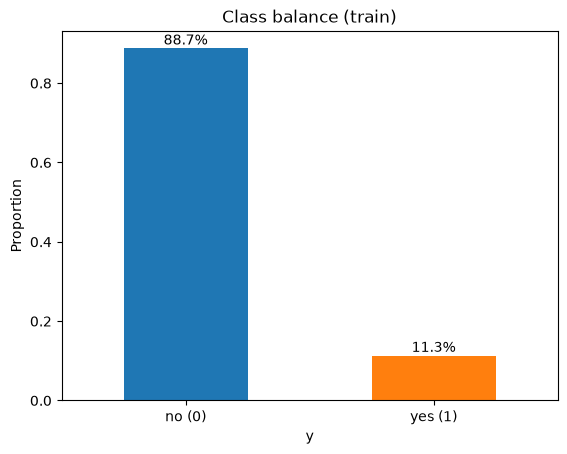

In [11]:
class_proportions = train_data["y"].value_counts(normalize=True)

ax = class_proportions.plot(kind="bar", color=["tab:blue", "tab:orange"])
ax.set_xticklabels(["no (0)", "yes (1)"], rotation=0)
ax.set_ylabel("Proportion")
ax.set_title("Class balance (train)")
for position, proportion in enumerate(class_proportions):
    ax.text(position, proportion + 0.01, f"{proportion:.1%}", ha="center")
plt.savefig(FIGURES_PATH / "01_class_balance.png", bbox_inches="tight")
plt.show()

## Numerical variables: distribution by class

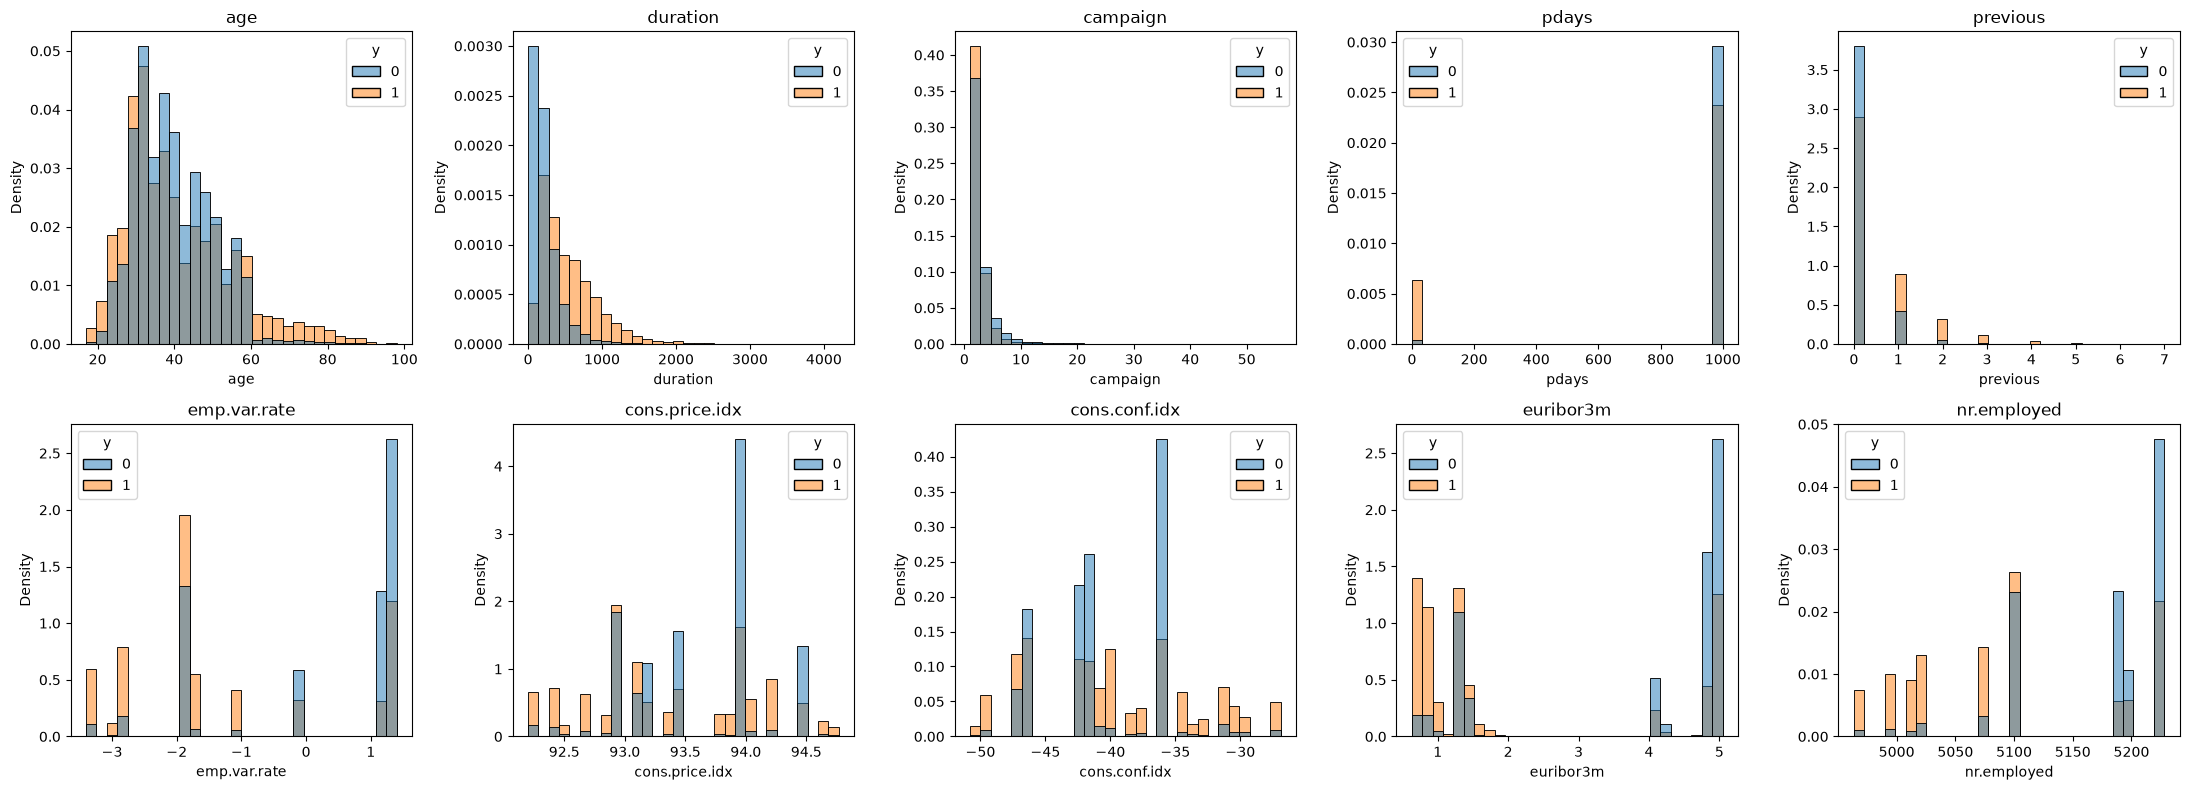

In [12]:
numerical_columns = train_data.select_dtypes(include="number").columns.drop("y")

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, column in zip(axes.flat, numerical_columns):
    sns.histplot(data=train_data, x=column, hue="y", stat="density",
                 common_norm=False, bins=30, ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "02_numerical_distributions_by_class.png", bbox_inches="tight")
plt.show()

## Mean of numerical variables: clients who accept vs. do not accept

In [13]:
train_data.groupby("y")[numerical_columns].mean().T.round(2)

y,0,1
age,39.89,41.03
duration,220.55,550.72
campaign,2.63,2.05
pdays,984.50,790.28
previous,0.13,0.49
emp.var.rate,0.24,-1.21
cons.price.idx,93.60,93.36
cons.conf.idx,-40.60,-39.81
euribor3m,3.81,2.14
nr.employed,5175.94,5095.76


## Data leakage: call duration is only known after the call

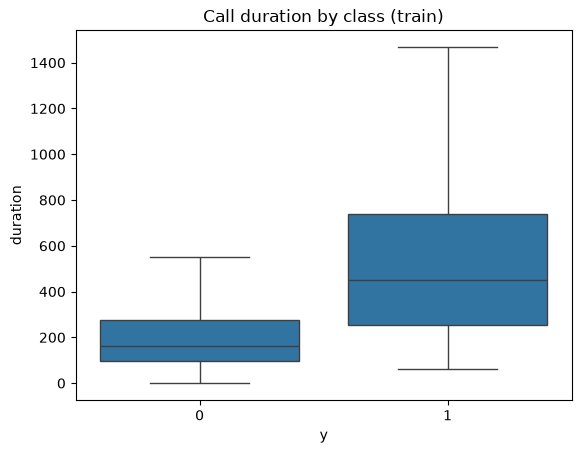

In [14]:
sns.boxplot(data=train_data, x="y", y="duration", showfliers=False)
plt.title("Call duration by class (train)")
plt.savefig(FIGURES_PATH / "03_duration_leakage.png", bbox_inches="tight")
plt.show()

## pdays: 999 means the client was never contacted before

In [15]:
never_contacted = train_data["pdays"] == 999
print(f"Never contacted: {never_contacted.mean():.1%}")
train_data.groupby(never_contacted)["y"].mean()

Never contacted: 96.3%


pdays
False    0.646230
True     0.092364
Name: y, dtype: float64

## Categorical variables: subscription rate per category

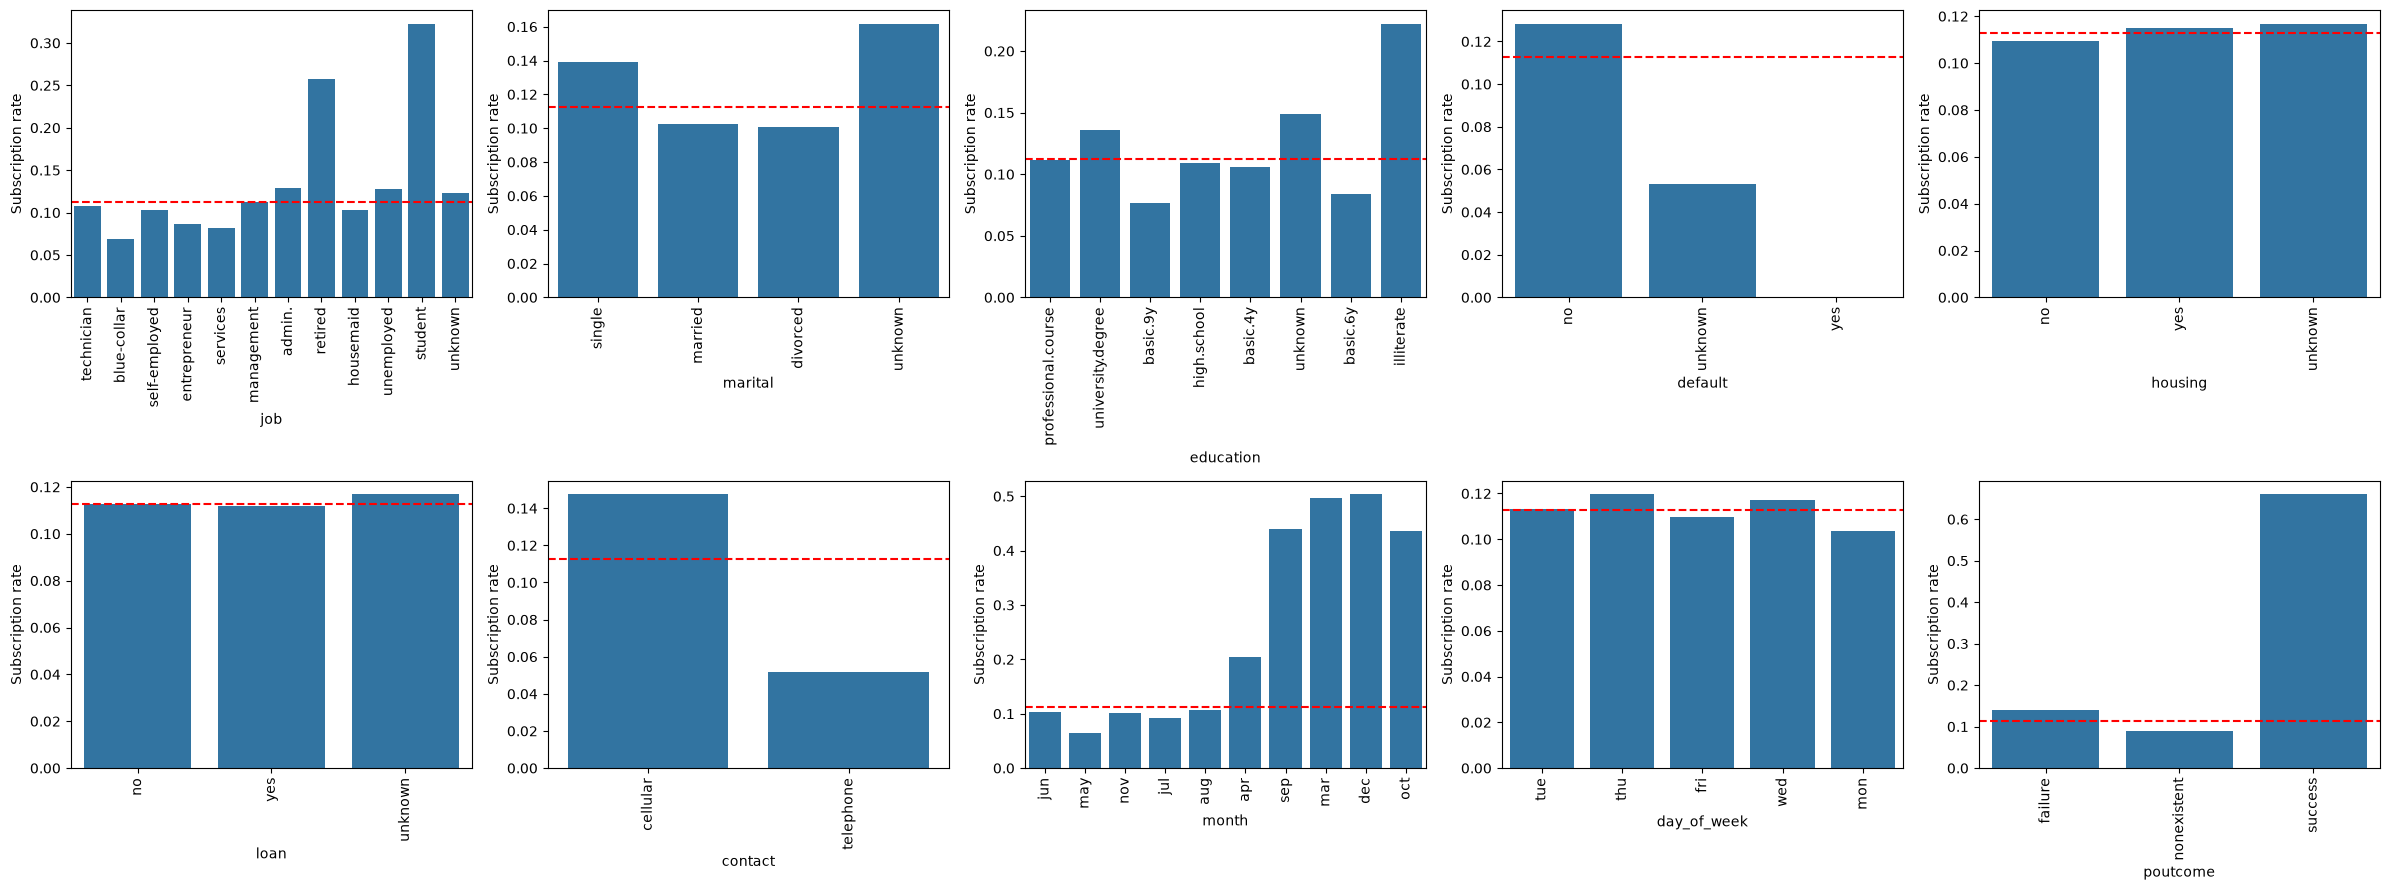

In [16]:
overall_subscription_rate = train_data["y"].mean()

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
for ax, column in zip(axes.flat, categorical_columns.drop("y")):
    sns.barplot(data=train_data, x=column, y="y", errorbar=None, ax=ax)
    ax.axhline(overall_subscription_rate, color="red", linestyle="--")
    ax.set_ylabel("Subscription rate")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "04_subscription_rate_by_category.png", bbox_inches="tight")
plt.show()

## Rare categories (less than 100 samples)

In [17]:
for column in categorical_columns.drop("y"):
    category_counts = train_data[column].value_counts()
    rare_categories = category_counts[category_counts < 100]
    if len(rare_categories) > 0:
        print(column, rare_categories.to_dict())

marital {'unknown': 68}
education {'illiterate': 18}
default {'yes': 2}


## Correlation matrix of numerical variables

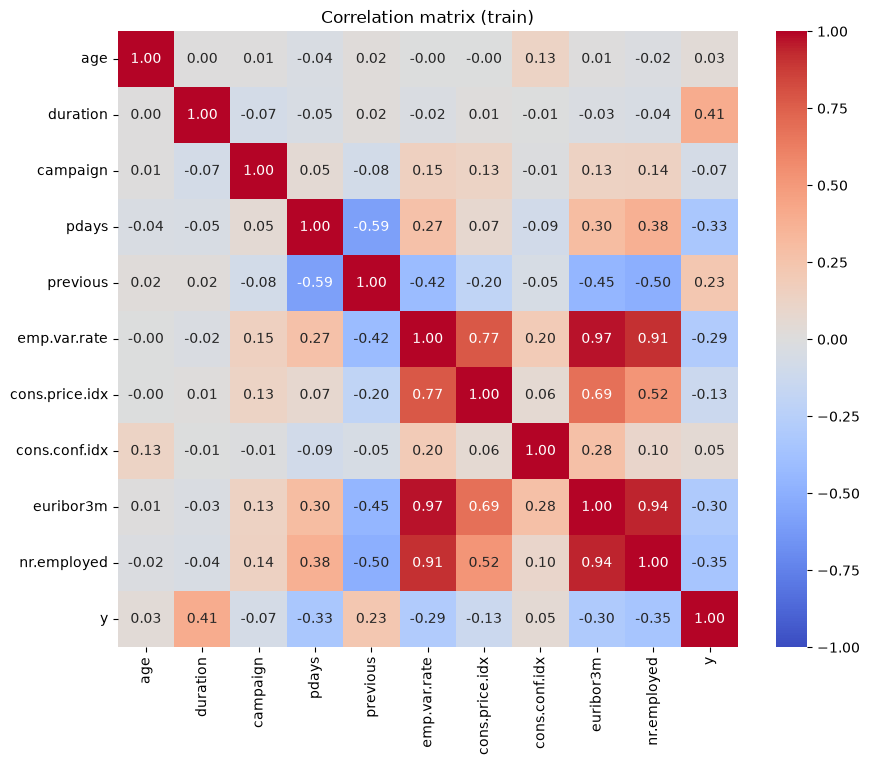

In [18]:
correlation_matrix = train_data[numerical_columns.tolist() + ["y"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix (train)")
plt.savefig(FIGURES_PATH / "05_correlation_matrix.png", bbox_inches="tight")
plt.show()

## Decisions from the EDA
- `duration`: removed (data leakage)
- `pdays`: replaced by binary `previously_contacted` (96% are 999)
- `emp.var.rate`, `euribor3m`: removed (correlation > 0.9 with `nr.employed`)
- `housing`, `loan`, `day_of_week`: removed (same subscription rate in every category)
- `"unknown"`: kept as its own category (e.g. `default` unknown → 5% vs 13%)
- Rare categories (< 100 samples): grouped in the pipeline (notebook 2)
- Numerical variables: standard scaling in the pipeline (notebook 2)
- Class imbalance (11% yes): stratified split and stratified k-fold

## Feature engineering (same row-wise transformation for train and test)

In [19]:
COLUMNS_TO_DROP = ["duration", "pdays", "emp.var.rate", "euribor3m",
                   "housing", "loan", "day_of_week"]


def engineer_features(data):
    engineered_data = data.copy()
    engineered_data["previously_contacted"] = (engineered_data["pdays"] != 999).astype(int)
    return engineered_data.drop(columns=COLUMNS_TO_DROP)


train_processed = engineer_features(train_data)
test_processed = engineer_features(test_data)
print(train_processed.shape, test_processed.shape)
train_processed.columns.tolist()

(32940, 15) (8236, 15)


['age',
 'job',
 'marital',
 'education',
 'default',
 'contact',
 'month',
 'campaign',
 'previous',
 'poutcome',
 'cons.price.idx',
 'cons.conf.idx',
 'nr.employed',
 'y',
 'previously_contacted']

## Save processed train and test sets

In [20]:
train_processed.to_csv(DATA_PATH / "train_processed.csv", index=False)
test_processed.to_csv(DATA_PATH / "test_processed.csv", index=False)